# Transcription Factor Project - Replogle et al. (2022) K562 Dataset Testing
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the KOLF2.1J genome-wide Perturb-seq dataset from the Nourreddine et al. (2024) preprint to investigate the effects of transcription factor knockdowns (TF KDs). Compare to the Replogle et al. (2022) K562 genome-wide Perturb-seq dataset to explore cell-type-specific transcriptional regulatory networks in hiPSCs vs. chronic myeloid leukemia cells.

**Guiding Questions:** What do TF KD effects reveal about:
* the transcriptional regulatory network of hiPSCs and K562 cells?
* TF crosstalk and co-regulation?
* cell lineage?
* how TFs influence chromatin remodeling?

***

# Import statements

In [ ]:
# Using psp_env virtual environment
import sys
import os
repo_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if repo_root not in sys.path:
    sys.path.insert(0, "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/")

import psp
import gc
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

In [ ]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style("ticks")
from scipy import sparse

# Data preprocessing: normalization, feature selection, subsetting KD cells only

In [ ]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_NTC_norm_KDefficiency_Etest_gRNA_filtered.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

AnnData object with n_obs × n_vars = 244096 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cel

Replogle-normalize data (UMI-normalize, then relative z-normalize)

In [ ]:
def replogle_normalize(adata: ad.AnnData,
                        batch_key: str="gem_group",
                        ctrl_key: str="perturbed",
                        ctrl_value: str="False",
                        UMI_count_key: str="UMI_count",
                        clip_min: float | None = None,
                        clip_max: float | None = 10,
                        counts_layer: str | None = None,
                        save_pre_norm_layer: bool=False,
                        pre_norm_layer: str | None = None,
                        save_norm_layer: bool=True,
                        norm_layer: str="replogle_norm") -> None:
    """
    Normalize to median NTC UMI count, relative z-normalize
    KD cells to NTC cells in the same batch, and clip values.
    Expects dataset with only core NTC cells. Expects counts in 
    adata.X or provided counts_layer.
    """
    # Save counts
    if save_pre_norm_layer:
        print(f"Saving pre-normalized data to '{pre_norm_layer}' layer")
        if pre_norm_layer in adata.layers:
            print(f"Overwriting existing '{pre_norm_layer}' layer")
        adata.layers[pre_norm_layer] = adata.X.copy()

    # Use counts layer if available, otherwise adata.X
    if counts_layer:
        if counts_layer in adata.layers:
            print(f"Setting .X to '{counts_layer}' layer")
            adata.X = adata.layers[counts_layer].copy()

    # Normalize to median NTC UMI count
    print("Normalizing .X to median NTC UMI count")
    median_umi_count = adata[adata.obs[ctrl_key] == ctrl_value
                             ].obs[UMI_count_key].median()
    sc.pp.normalize_total(adata, target_sum=median_umi_count)
    
    # Pull out dense X as a numpy array
    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()     # now X is (n_obs, n_vars) numpy
    else:
        X = X.copy()        # be safe if adata.X is a view

    out = np.zeros_like(X)  # final z-normalized pseudobulk

    # For each batch, compute mu/std on controls and fill out
    print("Performing relative z-normalization on .X")
    obs = adata.obs
    for batch in obs[batch_key].unique():
        mask_batch = (obs[batch_key] == batch).values
        mask_ctrl  = mask_batch & (obs[ctrl_key] == ctrl_value).values

        # get control pseudocounts and compute mean/std per gene
        ctrl_mat = X[mask_ctrl]           # shape (#ctrl_cells, n_vars)
        mu  = ctrl_mat.mean(axis=0)       # (n_vars,)
        std = ctrl_mat.std(axis=0)
        # prevent divide-by-zero error temporarily
        zero_std_mask = (std == 0)
        std[zero_std_mask] = 1.0  

        # z-normalize all cells in this batch
        # broadcasting: (n_cells_in_batch, n_vars) - (n_vars,) / (n_vars,)
        out[mask_batch] = (X[mask_batch] - mu) / std
        # set values where std = 0 to NaN
        out[mask_batch][:, zero_std_mask] = np.nan

    # Clip in-place
    print(f"Clipping values of .X to [{clip_min}, {clip_max}]")
    np.clip(out, clip_min, clip_max, out=out)

    # Write back
    adata.X = out

    # Save to new layer
    if save_norm_layer:
        print(f"Saving normalized data to '{norm_layer}' layer")
        if norm_layer in adata.layers:
            print(f"Overwriting existing '{norm_layer}' layer")
        adata.layers[norm_layer] = adata.X.copy()
        print(f"Normalized data stored in .X and '{norm_layer}' layer")
    else:
        print(f"Normalized data stored in .X")

In [ ]:
replogle_normalize(adata_k562, batch_key="gem_group", 
                   ctrl_key="perturbed", ctrl_value="False",
                   counts_layer="counts", UMI_count_key="UMI_count", 
                   clip_min=-10, clip_max=10,
                   save_norm_layer=False)

Setting .X to 'counts' layer
Normalizing .X to median NTC UMI count
normalizing counts per cell


    finished (0:00:01)
Performing relative z-normalization on .X
Clipping values of .X to [-10, 10]
Normalized data stored in .X


Feature selection: DEGs with pval < 0.005 and |LFC| > 0.25 in any KD condition

In [ ]:
def build_3_run_DEGs_dict(DE_results_1: pd.DataFrame, 
                          DE_results_2: pd.DataFrame,
                          DE_results_3: pd.DataFrame,
                          p_threshold: float,
                          p_threshold_type: str="pvalue",
                          lfc_threshold: float = 0
                          ) -> dict:
    # Check that 3 DGE analysis results DFs have same rows and cols
    DE_results_1 = DE_results_1.sort_index()
    DE_results_2 = DE_results_2.sort_index()
    DE_results_3 = DE_results_3.sort_index()
    if not (DE_results_1.index.equals(DE_results_2.index) and 
            DE_results_2.index.equals(DE_results_3.index)):
        raise ValueError("DGE results DataFrames must have same index (genes)")
    if not ((set(DE_results_1.columns) == set(DE_results_2.columns)) &
            (set(DE_results_2.columns) == set(DE_results_3.columns))):
        raise ValueError("DGE results DataFrames must have same columns (KDs)")
    # Check for valid significance threshold
    if p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("p_threshold_type must be 'pvalue' or 'padj'")
    
    # Find genes that are DEGs of the same KD in at least 2 DGE runs
    kds = {col.split("_")[0] for col in DE_results_1.columns}
    kds = sorted(list(kds))
    DEGs_dict = dict()
    for kd in kds:
        kd_p_col = f"{kd}_{p_threshold_type}"
        kd_lfc_col = f"{kd}_log2FoldChange"
        DEGs_run1 = set(DE_results_1.loc[(DE_results_1[kd_p_col] < p_threshold) & 
                                         (abs(DE_results_1[kd_lfc_col]) > lfc_threshold)].index)
        DEGs_run2 = set(DE_results_2.loc[(DE_results_2[kd_p_col] < p_threshold) & 
                                         (abs(DE_results_2[kd_lfc_col]) > lfc_threshold)].index)
        DEGs_run3 = set(DE_results_3.loc[(DE_results_3[kd_p_col] < p_threshold) & 
                                         (abs(DE_results_3[kd_lfc_col]) > lfc_threshold)].index)                                 
        DEGs_at_least_2 = ((DEGs_run1 & DEGs_run2) | (DEGs_run2 & DEGs_run3) |
                           (DEGs_run1 & DEGs_run3))
        DEGs_dict[kd] = DEGs_at_least_2
    return DEGs_dict

def get_DEG_feature_set(DEGs_dict: dict):
    return {gene for DEG_set in DEGs_dict.values() for gene in DEG_set}

def build_n_DEGs_df(DE_results_df: pd.DataFrame, 
                    alpha: float, 
                    threshold_type: str="pvalue", 
                    target_type: str="gRNA"):
    """
    Build a DF of the number of DEGs that pass significance threshold
    per gRNA or gene target.
    """
    if (target_type != "gRNA") & (target_type != "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target")
    if (threshold_type != "pvalue") & (threshold_type != "padj"):
        raise ValueError("threshold_type must be 'pvalue' or 'padj'")
    if target_type == "gRNA":
        targets = {"_".join(col.split("_")[:2]) for col in DE_results_df.columns}
    else:
        targets = {col.split("_")[0] for col in DE_results_df.columns}
    targets = list(sorted(list(targets)))
    DEGs_arr = np.zeros(len(targets), dtype=int)
    for i, target in enumerate(targets):
        target_p_col = f"{target}_{threshold_type}"
        n_DEGs = len(DE_results_df.loc[DE_results_df[target_p_col] < alpha])
        DEGs_arr[i] = n_DEGs
    n_DEGs_df = pd.DataFrame(DEGs_arr, index=targets, columns=["n_DEGs"])
    return n_DEGs_df

def build_mean_n_DEGs_df(n_DEGs_df_1: pd.DataFrame, 
                         n_DEGs_df_2: pd.DataFrame, 
                         n_DEGs_df_3: pd.DataFrame,
                         n_DEGs_col: str="n_DEGs"):
    n_DEGs_df_1 = n_DEGs_df_1.sort_index()
    n_DEGs_df_2 = n_DEGs_df_2.sort_index()
    n_DEGs_df_3 = n_DEGs_df_3.sort_index()
    if not (n_DEGs_df_1.index.equals(n_DEGs_df_2.index) and 
            n_DEGs_df_2.index.equals(n_DEGs_df_3.index)):
        raise ValueError("DataFrames must have same index")
    mean_n_DEGs_df = pd.DataFrame({"n_DEGs_1": n_DEGs_df_1[n_DEGs_col],
                                    "n_DEGs_2": n_DEGs_df_2[n_DEGs_col],
                                    "n_DEGs_3": n_DEGs_df_3[n_DEGs_col]},
                                    index=n_DEGs_df_1.index)
    mean_n_DEGs_df[n_DEGs_col] = mean_n_DEGs_df.mean(axis=1).astype(int)
    return mean_n_DEGs_df.drop(columns=["n_DEGs_1", "n_DEGs_2", "n_DEGs_3"])

In [ ]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)

In [ ]:
n_degs_df_k562_1 = build_n_DEGs_df(de_results_k562_1, alpha=0.005, threshold_type="pvalue", 
                                 target_type="gene_target")
n_degs_df_k562_2 = build_n_DEGs_df(de_results_k562_2, alpha=0.005, threshold_type="pvalue", 
                                 target_type="gene_target")
n_degs_df_k562_3 = build_n_DEGs_df(de_results_k562_3, alpha=0.005, threshold_type="pvalue", 
                                 target_type="gene_target")
mean_n_degs_df = build_mean_n_DEGs_df(n_degs_df_k562_1, n_degs_df_k562_2, n_degs_df_k562_3)
mean_n_degs_df.sort_values(by="n_DEGs", ascending=False).head(20)

,n_DEGs
DNMT1,443
CXXC1,188
MAX,169
MYB,155
TFDP1,148
ETV4,127
TBX1,126
SETDB1,121
NKX6-1,117
POU3F1,92


In [ ]:
kd_degs_dict = build_3_run_DEGs_dict(
    de_results_k562_1, de_results_k562_2, de_results_k562_3,
    p_threshold=0.005, lfc_threshold=0.25)
degs_k562 = get_DEG_feature_set(kd_degs_dict)
print(len(degs_k562))

2519


Filter genes to DEGs only

In [ ]:
adata_k562_mde = adata_k562[:, adata_k562.var_names.isin(degs_k562)]
adata_k562_mde

View of AnnData object with n_obs × n_vars = 244096 × 2519
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb'

Filter cells to TF KD cells only

In [ ]:
adata_k562_mde = adata_k562_mde[adata_k562_mde.obs.perturbed == "True"].copy()
adata_k562_mde

AnnData object with n_obs × n_vars = 193388 × 2519
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cel

# Pairwise Pearson correlation matrices

In [ ]:
import numpy as np
import pandas as pd
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, parallel_backend, delayed
import matplotlib.pyplot as plt
import seaborn as sns

def compute_mean_profile(adata, group_indices):
    mean_vector = adata.X[group_indices, :].mean(axis=0)
    return mean_vector.A1 if hasattr(mean_vector, 'A1') else mean_vector

def create_corrmatrix(adata: ad.AnnData, 
                    gene_target_obs_key: str="gene_target",
                    title: str='', 
                    mode: str='perturb', 
                    vmax: float | None = None, 
                    vmin: float | None = None, 
                    n_jobs: int=20, 
                    figsize: tuple[int, int] = (8,8)):
    """
    Version of psp.da.create_corrmatrix() that takes 
    gene_target_obs_key, n_jobs, and figsize as arguments
    and changes code to get gene target indices without 
    causing SettingWithCopyWarning.
    """
    # Get indices of each gene target
    gene_target_groups = adata.obs.groupby(gene_target_obs_key).indices
    # Initialize tqdm progress bar
    with tqdm_joblib(desc="Computing mean profiles", 
                     total=len(gene_target_groups)) as progress_bar:
        # Compute the mean expression profile for each group in parallel
        with parallel_backend('threading'):
            mean_profiles = Parallel(n_jobs=n_jobs)(
                delayed(compute_mean_profile)(adata, indices) 
                for indices in gene_target_groups.values()
            )
    mean_profiles = pd.DataFrame(np.array(mean_profiles).T, index=list(adata.var.index),
                                 columns=list(gene_target_groups.keys()))
    if mode == 'perturb':
        corr_matrix = np.corrcoef(mean_profiles.T)
        distance_df = pd.DataFrame(corr_matrix, index=mean_profiles.columns, 
                                   columns=mean_profiles.columns)
    elif mode == 'gene':
        corr_matrix = np.corrcoef(mean_profiles)
        distance_df = pd.DataFrame(corr_matrix, index=mean_profiles.index, 
                                   columns=mean_profiles.index)
    lim = np.percentile(abs(corr_matrix.flatten()), 98)
    if vmax is None:
        vmax = lim
    if vmin is None:
        vmin = -lim
    fig = sns.clustermap(distance_df,cmap="RdBu",xticklabels=False, yticklabels=False, center=0, 
        vmax=vmax, vmin=vmin, figsize=figsize)
    fig.ax_heatmap.set_xlabel('')
    fig.ax_heatmap.set_ylabel('');
    fig.ax_heatmap.set_title(title)
    fig.ax_row_dendrogram.set_visible(False)
    fig.ax_col_dendrogram.set_visible(False)
    return(fig,distance_df,mean_profiles)

## All TF KDs

Computing mean profiles:   0%|          | 0/916 [00:00<?, ?it/s]

/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


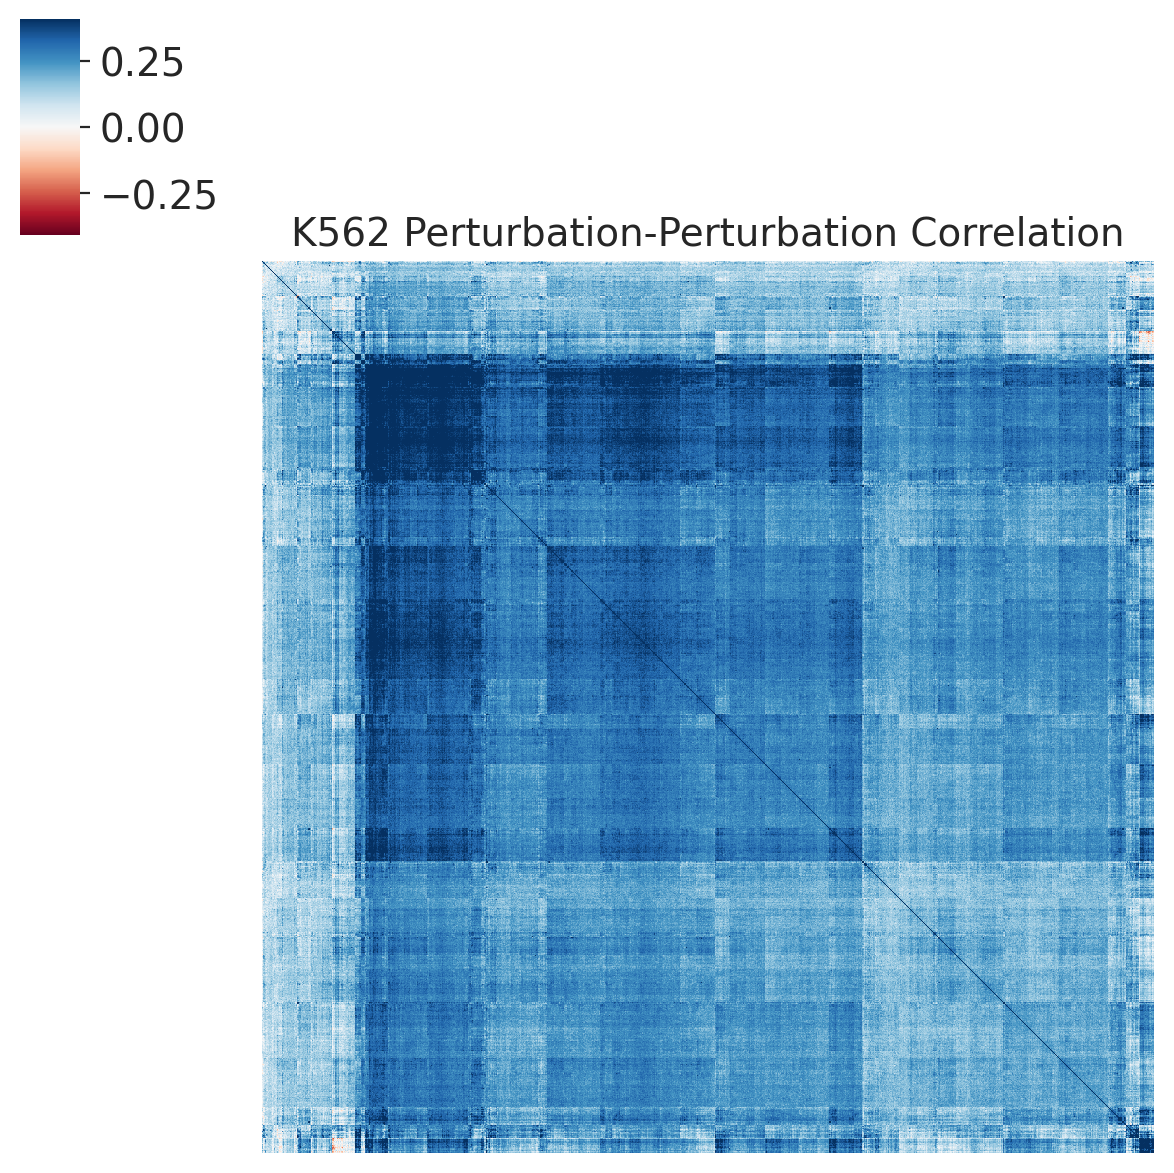

In [ ]:
perturb_corr_fig, perturb_corrs, perturb_mean_profiles = \
    create_corrmatrix(adata_k562_mde, 
                      gene_target_obs_key="gene",
                      mode="perturb", 
                      figsize=(6,6),
                      title="K562 Perturbation-Perturbation Correlation")

Computing mean profiles:   0%|          | 0/916 [00:00<?, ?it/s]

/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


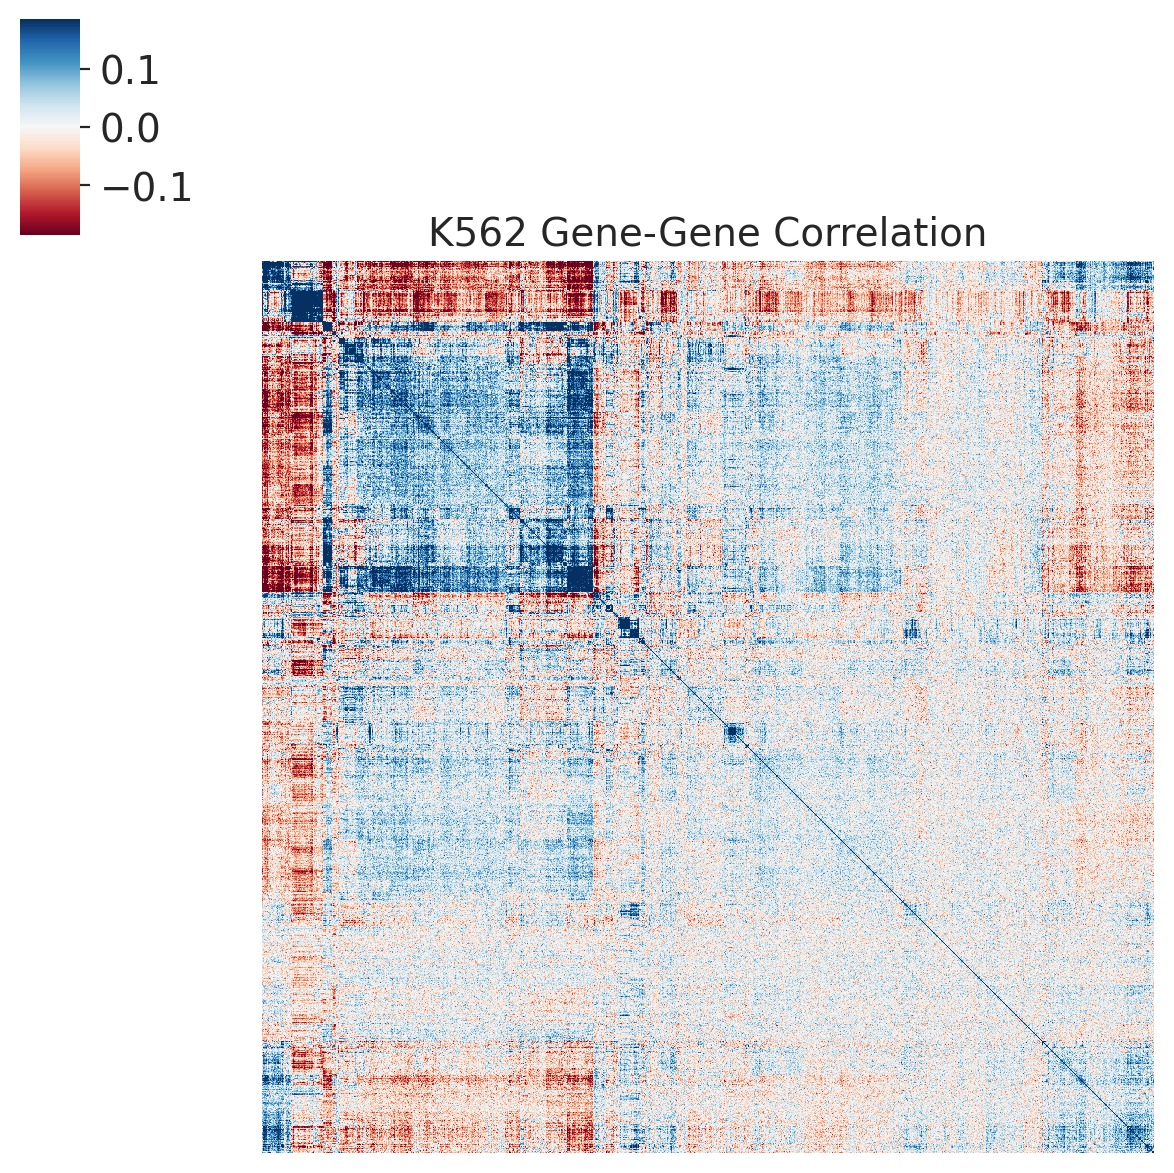

In [ ]:
gene_corr_fig, gene_corrs, gene_mean_profiles = \
    create_corrmatrix(adata_k562_mde, gene_target_obs_key="gene",
                      mode="gene", figsize=(6,6),
                      title="K562 Gene-Gene Correlation")

## Strong TF KDs

In [ ]:
def build_n_DEGs_df(DE_results_df: pd.DataFrame, 
                    alpha: float, 
                    threshold_type: str="pvalue", 
                    target_type: str="gRNA"):
    """
    Build a DF of the number of DEGs that pass significance threshold
    per gRNA or gene target.
    """
    if (target_type != "gRNA") & (target_type != "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target")
    if (threshold_type != "pvalue") & (threshold_type != "padj"):
        raise ValueError("threshold_type must be 'pvalue' or 'padj'")
    if target_type == "gRNA":
        targets = {"_".join(col.split("_")[:2]) for col in DE_results_df.columns}
    else:
        targets = {col.split("_")[0] for col in DE_results_df.columns}
    targets = list(sorted(list(targets)))
    DEGs_arr = np.zeros(len(targets), dtype=int)
    for i, target in enumerate(targets):
        target_p_col = f"{target}_{threshold_type}"
        n_DEGs = len(DE_results_df.loc[DE_results_df[target_p_col] < alpha])
        DEGs_arr[i] = n_DEGs
    n_DEGs_df = pd.DataFrame(DEGs_arr, index=targets, columns=["n_DEGs"])
    return n_DEGs_df

def get_3_run_strong_KDs(DE_results_1: pd.DataFrame,
                        DE_results_2: pd.DataFrame,
                        DE_results_3: pd.DataFrame,
                        p_threshold: float,
                        p_threshold_type: str="pvalue",
                        strong_kd_threshold: int = 10,
                        n_degs_col: str = "n_DEGs"):
    """
    Get strong KDs that have at least strong_kd_threshold DEGs
    in 2 out of 3 DGE analysis runs.
    """
    # Build n DEGs DFs
    n_DEGs_df_1 = build_n_DEGs_df(DE_results_1, alpha=p_threshold,
                                  threshold_type=p_threshold_type,
                                  target_type="gene_target")
    n_DEGs_df_2 = build_n_DEGs_df(DE_results_2, alpha=p_threshold,
                                  threshold_type=p_threshold_type,
                                  target_type="gene_target")
    n_DEGs_df_3 = build_n_DEGs_df(DE_results_3, alpha=p_threshold,
                                  threshold_type=p_threshold_type,
                                  target_type="gene_target")
    
    # Check that all n DEGs DFs have same index
    n_DEGs_df_1 = n_DEGs_df_1.sort_index()
    n_DEGs_df_2 = n_DEGs_df_2.sort_index()
    n_DEGs_df_3 = n_DEGs_df_3.sort_index()
    if not (n_DEGs_df_1.index.equals(n_DEGs_df_2.index) and 
            n_DEGs_df_2.index.equals(n_DEGs_df_3.index)):
        raise ValueError("DataFrames must have same index")
    
    # Strong KDs in each run
    kds_strong_run1 = set(n_DEGs_df_1[n_DEGs_df_1[n_degs_col] >= strong_kd_threshold].index)
    kds_strong_run2 = set(n_DEGs_df_2[n_DEGs_df_2[n_degs_col] >= strong_kd_threshold].index)
    kds_strong_run3 = set(n_DEGs_df_3[n_DEGs_df_3[n_degs_col] >= strong_kd_threshold].index)
    # KDs that are strong in at least 2 runs
    kds_strong_at_least_2 = ((kds_strong_run1 & kds_strong_run2) | 
                             (kds_strong_run2 & kds_strong_run3) |
                             (kds_strong_run1 & kds_strong_run3))
    return kds_strong_at_least_2

In [ ]:
strong_kds = get_3_run_strong_KDs(
    de_results_k562_1, de_results_k562_2, de_results_k562_3,
    p_threshold=0.005, p_threshold_type="pvalue", strong_kd_threshold=10)
print(len(strong_kds))

384


In [ ]:
adata_k562_mde_strong = adata_k562_mde[adata_k562_mde.obs.gene.isin(strong_kds)].copy()
print(f"{adata_k562_mde_strong.obs.gene.nunique()} TF KDs with 10+ DEGs")

384 TF KDs with 10+ DEGs


Computing mean profiles:   0%|          | 0/384 [00:00<?, ?it/s]

/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
/home/ranwyl/psp_env/lib64/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


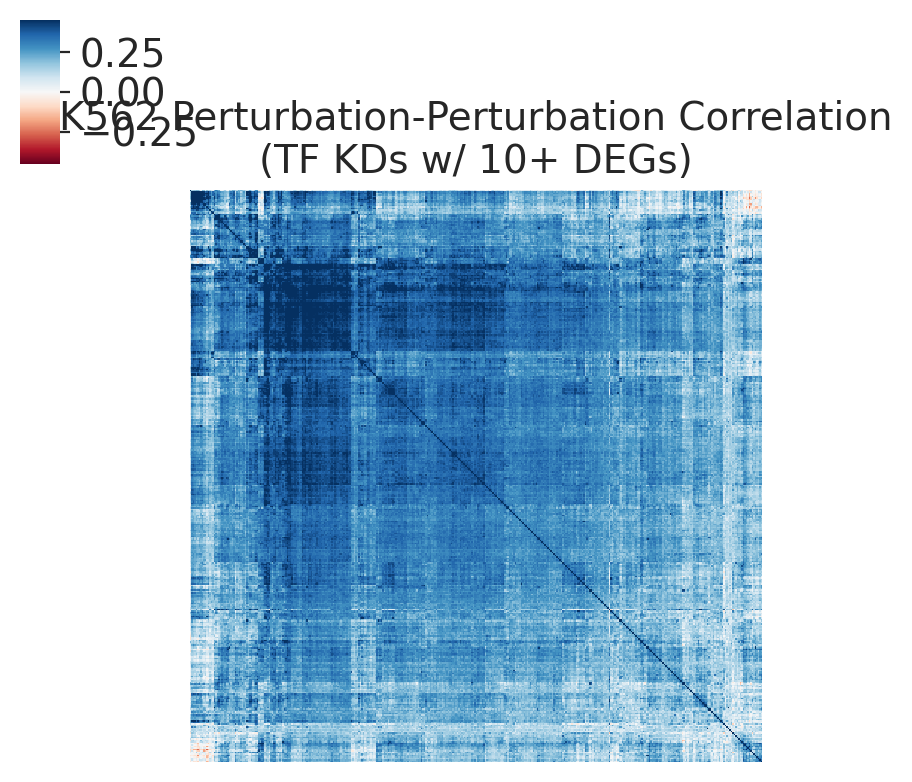

In [ ]:
perturb_corr_fig_strong, perturb_corrs_strong, perturb_mean_profiles_strong = \
    create_corrmatrix(adata_k562_mde_strong, 
                      gene_target_obs_key="gene",
                      mode="perturb", 
                      figsize=(4,4),
                      title="K562 Perturbation-Perturbation Correlation\n(TF KDs w/ 10+ DEGs)")

## Testing Replogle-normalization timing

Check which cells and TF KDs are common between datasets

In [ ]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_NTC_KDefficiency_Etest_gRNA_filtered.h5ad"
adata_k562_not_renorm = psp.utils.read_anndata(filepath)
adata_k562_not_renorm

AnnData object with n_obs × n_vars = 125345 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mea

In [ ]:
adata_k562_renorm_kd_cells = set(adata_k562[adata_k562.obs.perturbed == "True"].obs_names)
adata_k562_not_renorm_kd_cells = set(adata_k562_not_renorm[
    adata_k562_not_renorm.obs.perturbed == "True"].obs_names)

In [ ]:
print(len(adata_k562_renorm_kd_cells))
print(len(adata_k562_not_renorm_kd_cells))

74835
74637


In [ ]:
print(len(adata_k562_renorm_kd_cells & adata_k562_not_renorm_kd_cells))

74637


In [ ]:
print(len(adata_k562_renorm_kd_cells - adata_k562_not_renorm_kd_cells))

198


In [ ]:
print(len(adata_k562_not_renorm_kd_cells - adata_k562_renorm_kd_cells))

0


Datasets differ by 198 TF KD cells

In [ ]:
adata_k562_renorm_tf_kds = set(adata_k562[adata_k562.obs.perturbed == "True"].obs.gene)
adata_k562_not_renorm_tf_kds = set(adata_k562_not_renorm[
    adata_k562_not_renorm.obs.perturbed == "True"].obs.gene)

In [ ]:
print(len(adata_k562_renorm_tf_kds))
print(len(adata_k562_not_renorm_tf_kds))

378
376


In [ ]:
print(len(adata_k562_renorm_tf_kds & adata_k562_not_renorm_tf_kds))

376


In [ ]:
print(adata_k562_renorm_tf_kds - adata_k562_not_renorm_tf_kds)
print(len(adata_k562_renorm_tf_kds - adata_k562_not_renorm_tf_kds))

{'ZNF107', 'THYN1'}
2


In [ ]:
print(adata_k562[adata_k562.obs.gene.isin(["ZNF107", "THYN1"])].shape[0])

198


Datasets differ by 2 TF KDs

Compute pairwise Pearson correlation matrix of TF KDs for non-renormalized dataset

In [ ]:
def transfer_data_layer(adata_without_layer: ad.AnnData,
                        adata_with_layer: ad.AnnData,
                        original_layer_name: str,
                        new_layer_name: str):
    """
    Transfer a data layer from adata_with_layer to adata_without_layer.
    """
    assert(original_layer_name in adata_with_layer.layers), \
        f"{original_layer_name} not found"
    
    # Align cells and genes
    common_cells = adata_without_layer.obs_names.intersection(adata_with_layer.obs_names)
    common_genes = adata_without_layer.var_names.intersection(adata_with_layer.var_names)
    print(f"Common cells: {len(common_cells)}")
    print(f"Common genes: {len(common_genes)}")
    
    # Subset both adata objects to common cells and genes
    adata_without_layer_sub = adata_without_layer[common_cells, common_genes].copy()
    adata_with_layer_sub = adata_with_layer[common_cells, common_genes].copy()

    # Check that cells and genes are in correct order
    assert all(adata_without_layer_sub.obs_names == adata_with_layer_sub.obs_names), \
        "Cell order mismatch"
    assert all(adata_without_layer_sub.var_names == adata_with_layer_sub.var_names), \
        "Gene order mismatch"

    # Transfer layer
    adata_without_layer_sub.layers[new_layer_name] = \
        adata_with_layer_sub.layers[original_layer_name]
    return adata_without_layer_sub

In [ ]:
adata_k562_mde_renorm = adata_k562_mde

In [ ]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_norm_NTC_filtered.h5ad"
adata_k562_not_renorm = psp.utils.read_anndata(filepath)
adata_k562_not_renorm

AnnData object with n_obs × n_vars = 351530 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts', 'replogle_norm'

In [ ]:
adata_k562_mde_not_renorm = transfer_data_layer(adata_without_layer=adata_k562_mde_renorm,
                                          adata_with_layer=adata_k562_not_renorm,
                                          original_layer_name="replogle_norm",
                                          new_layer_name="replogle_norm_after_basic_qc")
adata_k562_mde_not_renorm.X = adata_k562_mde_not_renorm.layers["replogle_norm_after_basic_qc"].copy()
adata_k562_mde_not_renorm

Common cells: 74835
Common genes: 2823


AnnData object with n_obs × n_vars = 74835 × 2823
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean

Pearson matrix with exact same cells and genes

In [ ]:
_ = create_corrmatrix(adata_k562_mde_not_renorm, 
                      gene_target_obs_key="gene",
                      mode="perturb", 
                      figsize=(6,6),
                      title="K562 Perturbation-Perturbation Correlation\n(norm after basic QC)")

Check stdev of NTC cell per-gene expression before and after removing outlier cells

In [ ]:
ntc_inliers = adata_k562[adata_k562.obs.perturbed == "False"].copy()

In [ ]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_filtered_TF_KD_NTC_raw_norm.h5ad"
adata_pre_ntc_cleaning = psp.utils.read_anndata(filepath)
adata_pre_ntc_cleaning

AnnData object with n_obs × n_vars = 373792 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts', 'replogle_norm'

In [ ]:
ntc_full = adata_pre_ntc_cleaning[adata_pre_ntc_cleaning.obs.perturbed == "False"].copy()

In [ ]:
print(ntc_inliers.shape[0])
print(ntc_full.shape[0])

50708
72970


In [ ]:
ntc_inliers_degs = ntc_inliers[:, ntc_inliers.var_names.isin(degs_k562)].copy()
ntc_full_degs = ntc_full[:, ntc_full.var_names.isin(degs_k562)].copy()

In [ ]:
std_inliers = np.std(ntc_inliers_degs.layers["counts"], axis=0)
std_full = np.std(ntc_full_degs.layers["counts"], axis=0)

In [ ]:
std_ratio = std_full / std_inliers
print(f"Std ratio range: {std_ratio.min():.3f} - {std_ratio.max():.3f}")
print(f"Std ratio CV: {np.std(std_ratio)/np.mean(std_ratio):.3f}")

Std ratio range: 0.952 - 4.976
Std ratio CV: 0.109


In [ ]:
std_ratio[std_ratio > 2]

array([2.041737 , 2.4730737, 2.348335 , 4.9756947, 2.076458 , 2.148807 ],
      dtype=float32)

In [ ]:
large_std = np.where(std_ratio > 2)[0]

# Get gene names
gene_names = adata_k562[:, adata_k562.var_names.isin(degs_k562)].var_names
large_std_genes = set(gene_names[large_std])
print("Genes with large stdev ratio", large_std_genes)

Genes with large stdev ratio {'TMEM158', 'PRG2', 'MT2A', 'DDIT3', 'IER3', 'JUN'}


In [ ]:
mean_inliers = np.mean(ntc_inliers_degs.layers["counts"], axis=0)
mean_full = np.mean(ntc_full_degs.layers["counts"], axis=0)

In [ ]:
mu_diff = mean_full - mean_inliers
print(f"Mu diff range: {mu_diff.min():.4f} - {mu_diff.max():.4f}")
print(f"Mu diff std: {mu_diff.std():.4f}")
print(f"Mu diff mean: {mu_diff.mean():.4f}")

Mu diff range: -10.7891 - 9.9764
Mu diff std: 0.4467
Mu diff mean: -0.0504


In [ ]:
mu_diff[mu_diff > 2]

array([9.976402], dtype=float32)

In [ ]:
mu_diff[mu_diff < -2]

array([ -2.2599316,  -2.749874 ,  -2.6097565,  -2.1383095,  -4.098648 ,
        -2.0210533,  -4.9517517,  -8.569305 ,  -9.060562 , -10.7890625,
        -4.338684 ], dtype=float32)

In [ ]:
large_neg = np.where(mu_diff < -2)[0]
large_pos = np.where(mu_diff > 2)[0]

# Get gene names
gene_names = adata_k562[:, adata_k562.var_names.isin(degs_k562)].var_names
large_neg_mu_diff_genes = set(gene_names[large_neg])
large_pos_mu_diff_genes = set(gene_names[large_pos])
large_mu_diff_genes = large_neg_mu_diff_genes | large_pos_mu_diff_genes
print("Genes with mu_diff < -2:", large_neg_mu_diff_genes)
print("Genes with mu_diff > 2:", large_pos_mu_diff_genes)
print("All genes with large mu_diff", large_mu_diff_genes)

Genes with mu_diff < -2: {'RPS2', 'MT-CO2', 'PTMA', 'RPS3', 'MT-ATP6', 'MT-CO1', 'RPL3', 'EEF1A1', 'MT-CO3', 'MT-ND4', 'NPM1'}
Genes with mu_diff > 2: {'MALAT1'}
All genes with large mu_diff {'RPS2', 'MT-CO2', 'PTMA', 'RPS3', 'MT-ATP6', 'MT-CO1', 'RPL3', 'EEF1A1', 'MT-CO3', 'MT-ND4', 'NPM1', 'MALAT1'}


In [ ]:
# For mu_diff
mu_threshold = 2 * mu_diff.std()  # ~2 SD from mean
print(f"Mu diff threshold: +/- {mu_threshold:.4f}")
large_mu_genes = np.where(np.abs(mu_diff - mu_diff.mean()) > mu_threshold)[0]

# For std ratio - look at genes that deviate most from the median ratio
std_ratio_median = np.median(std_ratio)
std_ratio_iqr = np.subtract(*np.percentile(std_ratio, [75, 25]))
std_threshold = 2 * std_ratio_iqr  # 2x the IQR from median
large_std_genes = np.where(np.abs(std_ratio - std_ratio_median) > std_threshold)[0]

print(f"Genes with large mu shift: {len(large_mu_genes)}")
print(f"Genes with large std ratio shift: {len(large_std_genes)}")

# Get gene names
print("Large mu genes:", gene_names[large_mu_genes])
print("Large std ratio genes:", gene_names[large_std_genes])

# Also look at overlap
overlap = np.intersect1d(large_mu_genes, large_std_genes)
print(f"Genes with both: {len(overlap)}", gene_names[overlap])

Mu diff threshold: +/- 0.8934
Genes with large mu shift: 53
Genes with large std ratio shift: 249
Large mu genes: Index(['RPL11', 'YBX1', 'RPS8', 'RPL5', 'NCL', 'PTMA', 'RPL32', 'RPL15',
       'RPSA', 'RPL14', 'RPL29', 'RPS23', 'RPS14', 'NPM1', 'RACK1', 'RPS18',
       'RPL10A', 'HSP90AB1', 'EEF1A1', 'RPS12', 'RPL7', 'RPS6', 'RPL12',
       'RPL7A', 'HBG2', 'FTH1', 'MALAT1', 'RPS3', 'GAPDH', 'RPL41', 'RPL6',
       'HBZ', 'RPS2', 'RPL13', 'RPL23', 'RPL19', 'NME2', 'RPS15', 'RPL18A',
       'RPL13A', 'RPS9', 'RPL28', 'RANBP1', 'RPL3', 'RPS4X', 'RPL10', 'MT-ND2',
       'MT-CO1', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND4', 'MT-CYB'],
      dtype='object', name='gene_name')
Large std ratio genes: Index(['ISG15', 'SMIM1', 'SH3BGRL3', 'SESN2', 'SNHG12', 'LAPTM5', 'TMEM54',
       'CSF3R', 'CAP1', 'JUN',
       ...
       'LGALS1', 'ARFGAP3', 'PIM3', 'TMSB4X', 'SAT1', 'TIMP1', 'ALAS2',
       'ARMCX3', 'BEX2', 'SLC6A8'],
      dtype='object', name='gene_name', length=249)
Genes with both: 4 In

In [ ]:
large_mu_gene_names = set(gene_names[large_mu_genes])
print(len(large_mu_gene_names))

53


In [ ]:
adata_k562_mde_not_renorm_gene_subset = \
    adata_k562_mde_not_renorm[:, ~adata_k562_mde_not_renorm.var_names.isin(large_mu_gene_names)].copy()
adata_k562_mde_not_renorm_gene_subset.shape

(74835, 2770)

In [ ]:
_ = create_corrmatrix(adata_k562_mde_not_renorm_gene_subset, 
                      gene_target_obs_key="gene",
                      mode="perturb", 
                      figsize=(6,6),
                      title="K562 Perturbation-Perturbation Correlation\n(norm after basic QC)")

In [ ]:
adata_k562_mde_renorm_gene_subset = \
    adata_k562_mde_renorm[:, ~adata_k562_mde_renorm.var_names.isin(large_mu_gene_names)].copy()
adata_k562_mde_renorm_gene_subset.shape

(74835, 2770)

In [ ]:
_ = create_corrmatrix(adata_k562_mde_renorm_gene_subset, 
                      gene_target_obs_key="gene",
                      mode="perturb", 
                      figsize=(6,6),
                      title="K562 Perturbation-Perturbation Correlation")

In [ ]:
import numpy as np
import pandas as pd
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, parallel_backend, delayed
import matplotlib.pyplot as plt
import seaborn as sns

def compute_mean_profile(adata, group_indices):
    mean_vector = adata.X[group_indices, :].mean(axis=0)
    return mean_vector.A1 if hasattr(mean_vector, 'A1') else mean_vector

def create_corrmatrix(adata: ad.AnnData, 
                    gene_target_obs_key: str="gene_target",
                    title: str='', 
                    mode: str='perturb', 
                    vmax: float | None = None, 
                    vmin: float | None = None, 
                    n_jobs: int=20, 
                    figsize: tuple[int, int] = (8,8)):
    """
    Version of psp.da.create_corrmatrix() that takes 
    gene_target_obs_key, n_jobs, and figsize as arguments
    and changes code to get gene target indices without 
    causing SettingWithCopyWarning.
    """
    # Get indices of each gene target
    gene_target_groups = adata.obs.groupby(gene_target_obs_key).indices
    # Initialize tqdm progress bar
    with tqdm_joblib(desc="Computing mean profiles", 
                     total=len(gene_target_groups)) as progress_bar:
        # Compute the mean expression profile for each group in parallel
        with parallel_backend('threading'):
            mean_profiles = Parallel(n_jobs=n_jobs)(
                delayed(compute_mean_profile)(adata, indices) 
                for indices in gene_target_groups.values()
            )
    mean_profiles = pd.DataFrame(np.array(mean_profiles).T, index=list(adata.var.index),
                                 columns=list(gene_target_groups.keys()))
    if mode == 'perturb':
        corr_matrix = np.corrcoef(mean_profiles.T)
        distance_df = pd.DataFrame(corr_matrix, index=mean_profiles.columns, 
                                   columns=mean_profiles.columns)
    elif mode == 'gene':
        corr_matrix = np.corrcoef(mean_profiles)
        distance_df = pd.DataFrame(corr_matrix, index=mean_profiles.index, 
                                   columns=mean_profiles.index)
    lim = np.percentile(abs(corr_matrix.flatten()), 98)
    if vmax is None:
        vmax = lim
    if vmin is None:
        vmin = -lim
    fig = sns.clustermap(distance_df,cmap="RdBu",xticklabels=False, yticklabels=False, center=0, 
        vmax=vmax, vmin=vmin, figsize=figsize)
    fig.ax_heatmap.set_xlabel('')
    fig.ax_heatmap.set_ylabel('');
    fig.ax_heatmap.set_title(title)
    fig.ax_row_dendrogram.set_visible(False)
    fig.ax_col_dendrogram.set_visible(False)
    return(fig,distance_df,mean_profiles)

### Generate pairwise Pearson corr mtx for data Replogle-normalized only after basic QC

Check which cells and TF KDs are common between datasets

In [ ]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_NTC_KDefficiency_Etest_gRNA_filtered.h5ad"
adata_k562_not_renorm = psp.utils.read_anndata(filepath)
adata_k562_not_renorm

AnnData object with n_obs × n_vars = 125345 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mea

In [ ]:
adata_k562_renorm_kd_cells = set(adata_k562[adata_k562.obs.perturbed == "True"].obs_names)
adata_k562_not_renorm_kd_cells = set(adata_k562_not_renorm[
    adata_k562_not_renorm.obs.perturbed == "True"].obs_names)

In [ ]:
print(len(adata_k562_renorm_kd_cells))
print(len(adata_k562_not_renorm_kd_cells))

74835
74637


In [ ]:
print(len(adata_k562_renorm_kd_cells & adata_k562_not_renorm_kd_cells))

74637


In [ ]:
print(len(adata_k562_renorm_kd_cells - adata_k562_not_renorm_kd_cells))

198


In [ ]:
print(len(adata_k562_not_renorm_kd_cells - adata_k562_renorm_kd_cells))

0


Datasets differ by 198 TF KD cells

In [ ]:
adata_k562_renorm_tf_kds = set(adata_k562[adata_k562.obs.perturbed == "True"].obs.gene)
adata_k562_not_renorm_tf_kds = set(adata_k562_not_renorm[
    adata_k562_not_renorm.obs.perturbed == "True"].obs.gene)

In [ ]:
print(len(adata_k562_renorm_tf_kds))
print(len(adata_k562_not_renorm_tf_kds))

378
376


In [ ]:
print(len(adata_k562_renorm_tf_kds & adata_k562_not_renorm_tf_kds))

376


In [ ]:
print(adata_k562_renorm_tf_kds - adata_k562_not_renorm_tf_kds)
print(len(adata_k562_renorm_tf_kds - adata_k562_not_renorm_tf_kds))

{'ZNF107', 'THYN1'}
2


In [ ]:
print(adata_k562[adata_k562.obs.gene.isin(["ZNF107", "THYN1"])].shape[0])

198


Datasets differ by 2 TF KDs

Compute pairwise Pearson correlation matrix of TF KDs for non-renormalized dataset

In [ ]:
def transfer_data_layer(adata_without_layer: ad.AnnData,
                        adata_with_layer: ad.AnnData,
                        original_layer_name: str,
                        new_layer_name: str):
    """
    Transfer a data layer from adata_with_layer to adata_without_layer.
    """
    assert(original_layer_name in adata_with_layer.layers), \
        f"{original_layer_name} not found"
    
    # Align cells and genes
    common_cells = adata_without_layer.obs_names.intersection(adata_with_layer.obs_names)
    common_genes = adata_without_layer.var_names.intersection(adata_with_layer.var_names)
    print(f"Common cells: {len(common_cells)}")
    print(f"Common genes: {len(common_genes)}")
    
    # Subset both adata objects to common cells and genes
    adata_without_layer_sub = adata_without_layer[common_cells, common_genes].copy()
    adata_with_layer_sub = adata_with_layer[common_cells, common_genes].copy()

    # Check that cells and genes are in correct order
    assert all(adata_without_layer_sub.obs_names == adata_with_layer_sub.obs_names), \
        "Cell order mismatch"
    assert all(adata_without_layer_sub.var_names == adata_with_layer_sub.var_names), \
        "Gene order mismatch"

    # Transfer layer
    adata_without_layer_sub.layers[new_layer_name] = \
        adata_with_layer_sub.layers[original_layer_name]
    return adata_without_layer_sub

In [ ]:
adata_k562_mde_renorm = adata_k562_mde

In [ ]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_norm_NTC_filtered.h5ad"
adata_k562_not_renorm = psp.utils.read_anndata(filepath)
adata_k562_not_renorm

AnnData object with n_obs × n_vars = 351530 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts', 'replogle_norm'

In [ ]:
adata_k562_mde_not_renorm = transfer_data_layer(adata_without_layer=adata_k562_mde_renorm,
                                          adata_with_layer=adata_k562_not_renorm,
                                          original_layer_name="replogle_norm",
                                          new_layer_name="replogle_norm_after_basic_qc")
adata_k562_mde_not_renorm.X = adata_k562_mde_not_renorm.layers["replogle_norm_after_basic_qc"].copy()
adata_k562_mde_not_renorm

Common cells: 74835
Common genes: 2823


AnnData object with n_obs × n_vars = 74835 × 2823
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean

Pearson matrix with exact same cells and genes

In [ ]:
_ = create_corrmatrix(adata_k562_mde_not_renorm, 
                      gene_target_obs_key="gene",
                      mode="perturb", 
                      figsize=(6,6),
                      title="K562 Perturbation-Perturbation Correlation\n(norm after basic QC)")

Check stdev of NTC cell per-gene expression before and after removing outlier cells

In [ ]:
ntc_inliers = adata_k562[adata_k562.obs.perturbed == "False"].copy()

In [ ]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_filtered_TF_KD_NTC_raw_norm.h5ad"
adata_pre_ntc_cleaning = psp.utils.read_anndata(filepath)
adata_pre_ntc_cleaning

AnnData object with n_obs × n_vars = 373792 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts', 'replogle_norm'

In [ ]:
ntc_full = adata_pre_ntc_cleaning[adata_pre_ntc_cleaning.obs.perturbed == "False"].copy()

In [ ]:
print(ntc_inliers.shape[0])
print(ntc_full.shape[0])

50708
72970


In [ ]:
ntc_inliers_degs = ntc_inliers[:, ntc_inliers.var_names.isin(degs_k562)].copy()
ntc_full_degs = ntc_full[:, ntc_full.var_names.isin(degs_k562)].copy()

In [ ]:
std_inliers = np.std(ntc_inliers_degs.layers["counts"], axis=0)
std_full = np.std(ntc_full_degs.layers["counts"], axis=0)

In [ ]:
std_ratio = std_full / std_inliers
print(f"Std ratio range: {std_ratio.min():.3f} - {std_ratio.max():.3f}")
print(f"Std ratio CV: {np.std(std_ratio)/np.mean(std_ratio):.3f}")

Std ratio range: 0.952 - 4.976
Std ratio CV: 0.109


In [ ]:
std_ratio[std_ratio > 2]

array([2.041737 , 2.4730737, 2.348335 , 4.9756947, 2.076458 , 2.148807 ],
      dtype=float32)

In [ ]:
large_std = np.where(std_ratio > 2)[0]

# Get gene names
gene_names = adata_k562[:, adata_k562.var_names.isin(degs_k562)].var_names
large_std_genes = set(gene_names[large_std])
print("Genes with large stdev ratio", large_std_genes)

Genes with large stdev ratio {'TMEM158', 'PRG2', 'MT2A', 'DDIT3', 'IER3', 'JUN'}


In [ ]:
mean_inliers = np.mean(ntc_inliers_degs.layers["counts"], axis=0)
mean_full = np.mean(ntc_full_degs.layers["counts"], axis=0)

In [ ]:
mu_diff = mean_full - mean_inliers
print(f"Mu diff range: {mu_diff.min():.4f} - {mu_diff.max():.4f}")
print(f"Mu diff std: {mu_diff.std():.4f}")
print(f"Mu diff mean: {mu_diff.mean():.4f}")

Mu diff range: -10.7891 - 9.9764
Mu diff std: 0.4467
Mu diff mean: -0.0504


In [ ]:
mu_diff[mu_diff > 2]

array([9.976402], dtype=float32)

In [ ]:
mu_diff[mu_diff < -2]

array([ -2.2599316,  -2.749874 ,  -2.6097565,  -2.1383095,  -4.098648 ,
        -2.0210533,  -4.9517517,  -8.569305 ,  -9.060562 , -10.7890625,
        -4.338684 ], dtype=float32)

In [ ]:
large_neg = np.where(mu_diff < -2)[0]
large_pos = np.where(mu_diff > 2)[0]

# Get gene names
gene_names = adata_k562[:, adata_k562.var_names.isin(degs_k562)].var_names
large_neg_mu_diff_genes = set(gene_names[large_neg])
large_pos_mu_diff_genes = set(gene_names[large_pos])
large_mu_diff_genes = large_neg_mu_diff_genes | large_pos_mu_diff_genes
print("Genes with mu_diff < -2:", large_neg_mu_diff_genes)
print("Genes with mu_diff > 2:", large_pos_mu_diff_genes)
print("All genes with large mu_diff", large_mu_diff_genes)

Genes with mu_diff < -2: {'RPS2', 'MT-CO2', 'PTMA', 'RPS3', 'MT-ATP6', 'MT-CO1', 'RPL3', 'EEF1A1', 'MT-CO3', 'MT-ND4', 'NPM1'}
Genes with mu_diff > 2: {'MALAT1'}
All genes with large mu_diff {'RPS2', 'MT-CO2', 'PTMA', 'RPS3', 'MT-ATP6', 'MT-CO1', 'RPL3', 'EEF1A1', 'MT-CO3', 'MT-ND4', 'NPM1', 'MALAT1'}


In [ ]:
# For mu_diff
mu_threshold = 2 * mu_diff.std()  # ~2 SD from mean
print(f"Mu diff threshold: +/- {mu_threshold:.4f}")
large_mu_genes = np.where(np.abs(mu_diff - mu_diff.mean()) > mu_threshold)[0]

# For std ratio - look at genes that deviate most from the median ratio
std_ratio_median = np.median(std_ratio)
std_ratio_iqr = np.subtract(*np.percentile(std_ratio, [75, 25]))
std_threshold = 2 * std_ratio_iqr  # 2x the IQR from median
large_std_genes = np.where(np.abs(std_ratio - std_ratio_median) > std_threshold)[0]

print(f"Genes with large mu shift: {len(large_mu_genes)}")
print(f"Genes with large std ratio shift: {len(large_std_genes)}")

# Get gene names
print("Large mu genes:", gene_names[large_mu_genes])
print("Large std ratio genes:", gene_names[large_std_genes])

# Also look at overlap
overlap = np.intersect1d(large_mu_genes, large_std_genes)
print(f"Genes with both: {len(overlap)}", gene_names[overlap])

Mu diff threshold: +/- 0.8934
Genes with large mu shift: 53
Genes with large std ratio shift: 249
Large mu genes: Index(['RPL11', 'YBX1', 'RPS8', 'RPL5', 'NCL', 'PTMA', 'RPL32', 'RPL15',
       'RPSA', 'RPL14', 'RPL29', 'RPS23', 'RPS14', 'NPM1', 'RACK1', 'RPS18',
       'RPL10A', 'HSP90AB1', 'EEF1A1', 'RPS12', 'RPL7', 'RPS6', 'RPL12',
       'RPL7A', 'HBG2', 'FTH1', 'MALAT1', 'RPS3', 'GAPDH', 'RPL41', 'RPL6',
       'HBZ', 'RPS2', 'RPL13', 'RPL23', 'RPL19', 'NME2', 'RPS15', 'RPL18A',
       'RPL13A', 'RPS9', 'RPL28', 'RANBP1', 'RPL3', 'RPS4X', 'RPL10', 'MT-ND2',
       'MT-CO1', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND4', 'MT-CYB'],
      dtype='object', name='gene_name')
Large std ratio genes: Index(['ISG15', 'SMIM1', 'SH3BGRL3', 'SESN2', 'SNHG12', 'LAPTM5', 'TMEM54',
       'CSF3R', 'CAP1', 'JUN',
       ...
       'LGALS1', 'ARFGAP3', 'PIM3', 'TMSB4X', 'SAT1', 'TIMP1', 'ALAS2',
       'ARMCX3', 'BEX2', 'SLC6A8'],
      dtype='object', name='gene_name', length=249)
Genes with both: 4 In

In [ ]:
large_mu_gene_names = set(gene_names[large_mu_genes])
print(len(large_mu_gene_names))

53


In [ ]:
adata_k562_mde_not_renorm_gene_subset = \
    adata_k562_mde_not_renorm[:, ~adata_k562_mde_not_renorm.var_names.isin(large_mu_gene_names)].copy()
adata_k562_mde_not_renorm_gene_subset.shape

(74835, 2770)

In [ ]:
_ = create_corrmatrix(adata_k562_mde_not_renorm_gene_subset, 
                      gene_target_obs_key="gene",
                      mode="perturb", 
                      figsize=(6,6),
                      title="K562 Perturbation-Perturbation Correlation\n(norm after basic QC)")

In [ ]:
adata_k562_mde_renorm_gene_subset = \
    adata_k562_mde_renorm[:, ~adata_k562_mde_renorm.var_names.isin(large_mu_gene_names)].copy()
adata_k562_mde_renorm_gene_subset.shape

(74835, 2770)

In [ ]:
_ = create_corrmatrix(adata_k562_mde_renorm_gene_subset, 
                      gene_target_obs_key="gene",
                      mode="perturb", 
                      figsize=(6,6),
                      title="K562 Perturbation-Perturbation Correlation")